In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
.. _uoi_lasso:

UoI-Lasso for sparse, minimal bias, regression
=============================r[i================

This example with demonstrate the ability of UoI-Lasso to recover sparse
models with minimal bias.

"""

###############################################################################
# Load synthetic data
# -------------------
#
# The synthetic data will have 40 features, 10 of which are informative and
# 1 response variable.


import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression, LassoCV

from pyuoi.linear_model import *
from pyuoi.datasets import make_linear_regression
import pandas as pd
from scipy.linalg import solve_discrete_lyapunov
from var_utils import *
from tqdm import tqdm

### Gaussian VAR model

In [56]:
n_features = 10
n_samples = 15
lag = 2


data, transition_matrices, cov = generate_sparse_stationary_var_process(
    n_features,
    n_samples,
    lag=lag,
    sparsity=0.5,
    spectral_radius=0.6,  # Ensures stationarity
    process_type='gaussian'

)

In [57]:
# vecortized the ground truth transition matrices
dense_matrices = [M.toarray() for M in  transition_matrices]
B_truth = np.vstack([m.T for m in dense_matrices]).T.flatten()   

# vectorizing the input data for the model
X,Y = vectorization(data, lag)

In [58]:
X.shape

(130, 200)

In [59]:
uoi_var = UoI_Lasso(n_real_features = n_features, fit_VAR = True)
uoi_var.fit(X, Y)
B_model = uoi_var.coef_

/Users/yao/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.194e-02, tolerance: 1.063e-02
  model = cd_fast.enet_coordinate_descent(
/Users/yao/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.441e-02, tolerance: 1.063e-02
  model = cd_fast.enet_coordinate_descent(
/Users/yao/anaconda3/envs/py39/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing 

In [60]:
selection_accuracy(B_truth, B_model)

0.1504424778761062

In [61]:
# estimation error
est_mask = B_model != 0
np.linalg.norm(B_truth*est_mask - B_model)**2

4.411594869486233

In [ ]:
# construct the lagged connectivity matrices from the model coefficient
A_model = [B_model.reshape(n_features,n_features*lag).T[i*n_features:(i+1)*n_features].T for i in range(lag)]

In [ ]:
# prediction
yhat = uoi_var.predict(X)

# converted back to time series array
true_response = Y.reshape((n_samples-lag,n_features),order = "F")  #shape: each row is a sample of length n_features
prediction = yhat.reshape((n_samples-lag,n_features),order = "F")

Text(0, 0.5, 'relative error between y_hat and y')

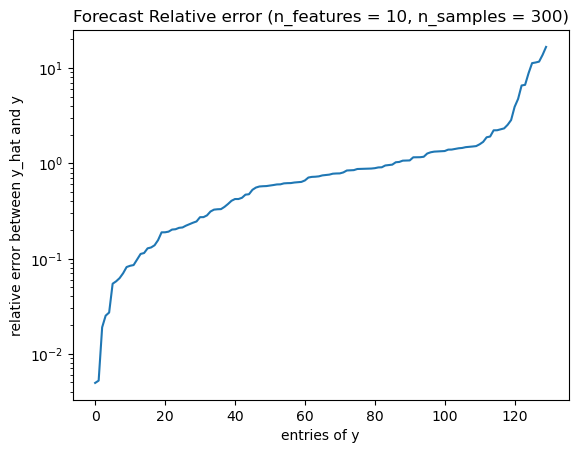

In [73]:
plt.plot(np.sort(np.abs((yhat - Y)/Y)))
plt.yscale("log")
plt.title("Prediction Relative error")
plt.xlabel("entries of y")
plt.ylabel("relative error between y_hat and y")

### Poisson VAR model

In [12]:
# Example usage
n_features = 10
n_samples = 10
lag = 1


base_intensity = np.random.randint(1, 10, n_features).astype(np.float64)  # Base rates for each feature

data, transition_matrices, _ = generate_sparse_stationary_var_process(
    n_features,
    n_samples,
    lag=lag,
    sparsity=0.5,
    quench_factor = 1, 
    spectral_radius=0.9,  # Ensures stationarity
    process_type='poisson',
    base_intensity=base_intensity

)

In [13]:
dense_matrices = [M.toarray() for M in  transition_matrices]
# vecortized the ground truth transition matrices
B_truth = np.vstack([m.T for m in dense_matrices]).T.flatten()     
X,Y = vectorization(data, lag)

In [14]:
# have to set fit_intercept = False since the curretn VAR implementation doesn consider constant model terms
poisson = UoI_Poisson(n_real_features = n_features, fit_VAR =True, max_iter=2500, fit_intercept=False)

poisson.fit(X, Y)

/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi

/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi

/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi/src/pyuoi/lbfgs/__init__.py:205: UserWarning: The algorithm routine reaches the maximum number of iterations.
  return opt.minimize(f, x0, progress=progress, args=args)
/Users/yao/packages/pyuoi

AttributeError: 'UoI_Poisson' object has no attribute 'estimation_target'

AttributeError: 'UoI_Poisson' object has no attribute 'estimation_target'

AttributeError: 'UoI_Poisson' object has no attribute 'estimation_target'

In [15]:
B_model = poisson.coef_
B_truth = np.vstack([m.toarray().T for m in transition_matrices]).T.flatten()
selection_accuracy(B_truth, B_model)

0.21311475409836067